In [12]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[0]  # importing functions from other folders
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from _data.data_utils import read_in
from _fitting.fitting_utils import hist_plot, CI_plot, CI_plot_alt, CI_plot_both, plot_posteriors_side_by_side, plot_spline_Bknots
import pymc as pm
import pymc.math as pmm
import arviz as az
from patsy import dmatrix
import nutpie
import time
from IPython.display import display
from pymc.variational.callbacks import CheckParametersConvergence
import io
import base64

az.style.use("arviz-darkgrid")


if '___laptop' in os.listdir('../'):
    # laptop folder
    folder = "../../_data/p-dengue/"
elif '___server' in os.listdir('../'):
    # server folder
    folder = "../../../../../data/lucaratzinger_data/p_dengue/"

%matplotlib inline
import warnings
import seaborn as sns

---
## Weather-Statistic-Dependent Zero Proportions

In [13]:
data = read_in(folder, admin=2, max_lag=6, dropna=True, start_year=2016, start_month=1, end_year=2020, end_month=12)

In [14]:
def plot_zero_proportion(data, stat_name, thresholds=None):
    if thresholds is None:
        thresholds = [0.8, 0.9, 0.95, 0.975, 0.99, 0.999]

    d = data.copy()
    stat_min, stat_max = np.min(d[stat_name]), np.max(d[stat_name])
    stat_vals = np.linspace(stat_min, stat_max, 1000)

    zero_prop = []
    for t in stat_vals:
        prop = np.mean(d.loc[d[stat_name] < t, 'cases'] == 0)
        zero_prop.append(prop)
    zero_prop = np.array(zero_prop)
    # Plot main curve
    plt.plot(stat_vals, zero_prop, lw=0.5)

    crossings = []
    cmap = plt.cm.cool
    first_label = {t: True for t in thresholds}
    # Detect threshold crossings
    for i, t in enumerate(thresholds):
        diff = zero_prop - t
        sign_change = np.where(np.diff(np.sign(diff)) != 0)[0]
        for idx in sign_change[1:]:
            x1, x2 = stat_vals[idx], stat_vals[idx+1]
            y1, y2 = zero_prop[idx], zero_prop[idx+1]

            x_cross = (x1+x2)/2

            crossings.append((t, x_cross, '▼' if np.sign(y2-t) < 0 else '▲'))

            color = cmap(i/len(thresholds))
            label = f"{t}" if first_label[t] else None
            first_label[t] = False

            plt.axvline(x_cross, alpha=0.6, color=color, lw=0.8, label=label)
    crossings_df = pd.DataFrame(crossings, columns=["threshold", stat_name, "direction"])
    crossings_df.dropna(inplace=True)
    crossings_df = crossings_df.sort_values([stat_name, "threshold"]).reset_index(drop=True)

    plt.xlabel(f'{stat_name} t', fontsize=12)
    plt.ylabel('Zero Proportion', fontsize=12)
    plt.title(f'Proportion of Zero Cases in Data with {stat_name} < t', fontsize=14)
    plt.grid()
    if len(crossings_df) > 0:
        plt.legend(title="threshold", fontsize=10)

    fig = plt.gcf()
    fig.set_dpi(250)

    return fig, crossings_df

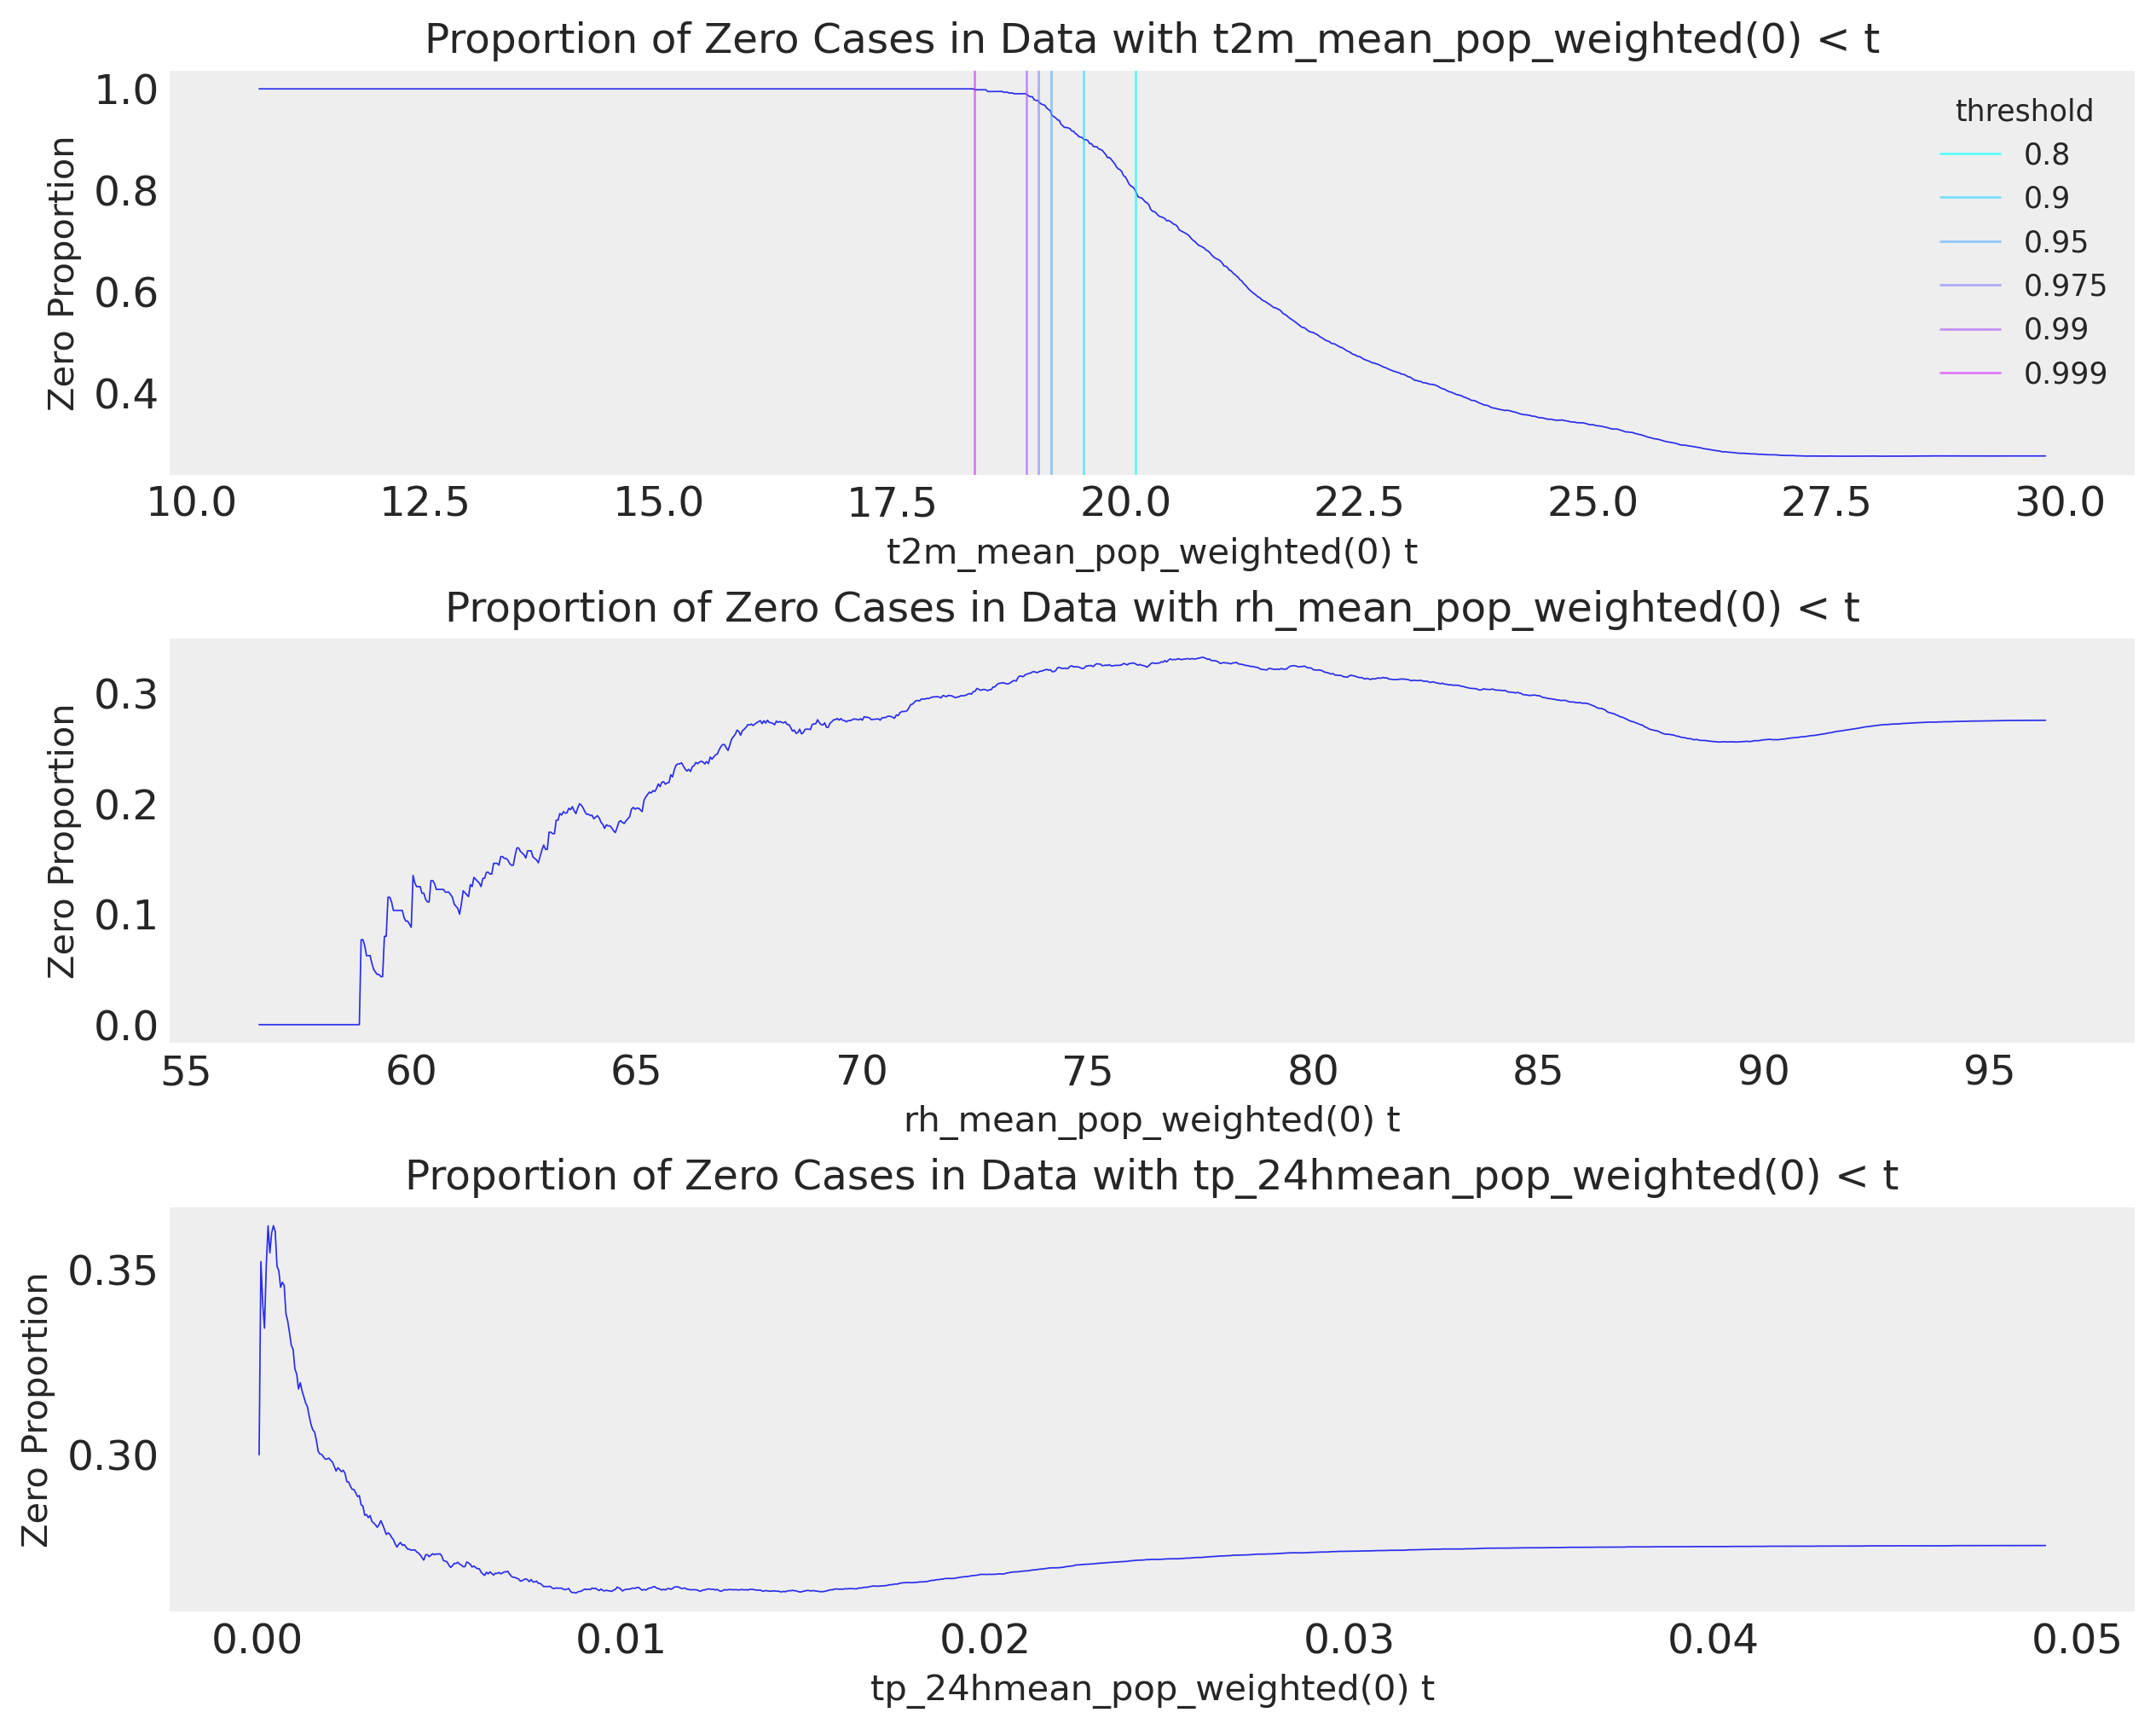

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

for ax, stat_name in zip(axes, ['t2m_mean_pop_weighted(0)', 'rh_mean_pop_weighted(0)', 'tp_24hmean_pop_weighted(0)']):
    plt.sca(ax)
    plot_zero_proportion(data, stat_name)
plt.show()

### Temperature shows a marked zero domain with strong suppression (proportion of zeros > 0.95) at 19.202

In [16]:
stat_name = 't2m_mean_pop_weighted(0)'
fig, crossings_df = plot_zero_proportion(data, stat_name)
plt.close()
display(crossings_df.round(3))

,threshold,t2m_mean_pop_weighted(0),direction
0,0.999,18.379,▼
1,0.990,18.934,▼
2,0.975,19.068,▼
3,0.950,19.202,▼
4,0.900,19.547,▼
5,0.800,20.103,▼


### We want to choose a cutoff where the spline in the log_mu of the count likelihood starts to explain the number of cases. Given the log link it struggles to push towards zero mean, and it is questionable that the count likelihood (poisson and negative binomial) is even appropriate to model all these zeroes. We can choose the cutoff where this happens, for example 19.00 degrees celsius. The sigmoid function (with a linear function of temperature as input) will handle the transition between the zero and non-zero domain and the spline will explain the behaviour in the non-zero domain.

---

## Models

In [17]:
def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=150)
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode("utf-8")
    plt.close(fig)
    return img_base64

In [18]:
def plot_link(x, idata, var_names=['zi_b0', 'zi_b1'], link='logit'):
    x_mean = np.mean(x)
    x_std_dev = np.std(x)
    
    b0_samples = idata.posterior[var_names[0]].values.flatten()
    b1_samples = idata.posterior[var_names[1]].values.flatten()

    x0_samples = -b0_samples / (b1_samples) * x_std_dev + x_mean
    x0_mean = np.mean(x0_samples)
    x0_lower = np.percentile(x0_samples, 2.5)
    x0_upper = np.percentile(x0_samples, 97.5)

    link_samples = np.array([b0 + b1 * ((x - x_mean) / x_std_dev) for b0, b1 in zip(b0_samples, b1_samples)])
    def logit_to_prob(logit):
        return 1 / (1 + np.exp(-logit))
    def probit_to_prob(probit):
        from scipy.special import erf
        return 0.5 * (1 + erf(probit / np.sqrt(2)))
    if link == 'logit':
        link_samples = logit_to_prob(link_samples)
    elif link == 'probit':
        link_samples = probit_to_prob(link_samples)
    
    link_mean = link_samples.mean(axis=0)
    link_lower5 = np.percentile(link_samples, 25, axis=0)
    link_upper5 = np.percentile(link_samples, 75, axis=0)
    link_lower = np.percentile(link_samples, 2.5, axis=0)
    link_upper = np.percentile(link_samples, 97.5, axis=0)

    # reorder
    id = np.argsort(x)
    x = x[id]
    link_mean = link_mean[id]
    link_lower5 = link_lower5[id]
    link_upper5 = link_upper5[id]
    link_lower = link_lower[id]
    link_upper = link_upper[id]
    link_hdi = np.array([link_lower, link_upper]).T
    plt.figure(figsize=(8, 5))

    plt.axvline(x0_mean, color='red', linestyle='--', label='Mean x0')
    plt.axvline(x0_lower, color='red', linestyle=':', label='95% CI x0')
    plt.axvline(x0_upper, color='red', linestyle=':')

    plt.plot(x, link_mean, label='Mean Link', color='blue')
    plt.fill_between(x, link_hdi[:, 0], link_hdi[:, 1], color='blue', alpha=0.3, label='95% HDI')
    plt.xlabel('x')
    plt.ylabel('Link(psi)')
    plt.title(f'Posterior of Inverse {link.capitalize()} vs x')
    plt.legend()
    plt.grid()
    return plt.gcf()

In [19]:
def elpd_to_row(eval_waic, eval_loo, model_name, data_name):
    return {"model_name": model_name,
            "data_name": data_name,
            # WAIC
            "waic": float(eval_waic.elpd_waic),
            #"p_waic": float(eval_waic.p_waic),
            "waic_se": float(eval_waic.se),
            "waic_warning": int(eval_waic.warning),
            # LOO
            "loo": float(eval_loo.elpd_loo),
            #"p_loo": float(eval_loo.p_loo),
            "loo_se": float(eval_loo.se),
            # diagnostics
            "n_pareto_k_bad": int(np.sum(eval_loo.pareto_k>0.7)),
            "n_pareto_k_very_bad": int(np.sum(eval_loo.pareto_k>1)),
            "pareto_k_mean": float(eval_loo.pareto_k.mean())}

def go(m, model_dict, idata_dict, time_dict, B_dict,
       knot_list_dict, link_dict, stat_names_dict, var_names_dict, n_divergences_dict,
       tune=1000, draws=4000, target_accept=0.8, max_treedepth=10, compute_idata=True):
    
    var_names = var_names_dict[m]
    stat_names = stat_names_dict[m]
    with model_dict[m]:
        if compute_idata:
            s0 = time.time()
            idata_dict[m] = pm.sample(
                tune=tune,
                draws=draws,
                chains=4,
                discard_tuned_samples=True,
                nuts_sampler="nutpie",
                store_divergences=True,
                target_accept=target_accept,
                max_treedepth=max_treedepth,
            )
            s1 = time.time()
            pm.compute_log_likelihood(idata_dict[m], progressbar=False)
            s2 = time.time()
            time_dict[m] = (s1 - s0, s2 - s1)
            n_divergences = int(idata_dict[m].sample_stats["diverging"].sum())
            n_divergences_dict[m] = n_divergences
    n_divergences = n_divergences_dict[m]
    # ---------- Summary table ----------
    summary_df = az.summary(idata_dict[m], var_names=var_names)
    summary_html = summary_df.to_html()

    # ---------- Trace plot ----------
    tp_var_names = [v for v in var_names if 'true_scale' not in v]
    fig_trace = az.plot_trace(idata_dict[m], var_names=tp_var_names)
    fig_trace = fig_trace.ravel()[0].figure
    trace_img = fig_to_base64(fig_trace)

    # ---------- Pair plot ----------
    az.rcParams["plot.max_subplots"] = 200
    pp_var_names = [v for v in var_names if 'true_scale' not in v]
    ax = az.plot_pair(
        idata_dict[m],
        var_names=pp_var_names,
        textsize=14,
        divergences=True)

    for i in range(ax.shape[0]):
        ax[i, 0].yaxis.label.set_rotation(0)
        ax[i, 0].yaxis.label.set_ha('right')
    for j in range(ax.shape[1]):
        ax[0, j].xaxis.label.set_rotation(45)
        ax[0, j].xaxis.label.set_ha('right')
    fig_pair = ax.ravel()[0].figure
    pair_img = fig_to_base64(fig_pair)

    #### WAIC and PSIS LOO
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        eval_waic = az.waic(idata_dict[m])
        eval_psis_loo_elpd = az.loo(idata_dict[m])
    wl_df = pd.DataFrame([elpd_to_row(eval_waic, eval_psis_loo_elpd, m, 'd')])
    wl_html = wl_df.to_html()

    # ---------- Spline plot ----------
    spline_imgs = []
    if stat_names is not None:
        for stat_name in stat_names:
            fig_spline = plot_spline_Bknots(
                idata_dict[m],
                stat_name,
                f'w({stat_name})',
                f'sigma_w({stat_name})',
                B_dict[m][stat_name],
                data[stat_name].values,
                knots=knot_list_dict[m][stat_name],
                show_basis=True,
                invert_log=True,
                centred_w=True
            )
            spline_imgs.append(fig_to_base64(fig_spline))
    
    if link_dict[m] is not None:
        link = link_dict[m]['link']
        link_stat_name = link_dict[m]['link_stat_name']
        zi_img = fig_to_base64(plot_link(data[link_stat_name].values, idata_dict[m],
                                         var_names=['zi_b0', 'zi_b1'], link=link))
    else:
        zi_img = None

    #---Divergences plot---
    if n_divergences > 0:
        posterior = idata_dict[m].posterior.to_dataframe().reset_index()
        stats = idata_dict[m].sample_stats.to_dataframe().reset_index()
        df = posterior.merge(stats, on=["chain","draw"])

        #posterior = az.extract(idata_dict[m], combined=True).to_pandas()
        #stats = idata_dict[m].sample_stats.to_dataframe()
        #df = posterior.join(stats)
        sns.pairplot( df, vars=pp_var_names, hue="diverging",
                    corner=True, diag_kind='kde', plot_kws={"alpha":0.5, 's':1}, diag_kws={"common_norm": False})
        div_img = fig_to_base64(plt.gcf())

    # ---------- Build HTML ----------
    html_content = f"""
    <html>
    <head>
        <title>Model Report: {m}</title>
        <style>
            body {{ font-family: Arial; margin: 40px; }}
            h1 {{ margin-bottom: 10px; }}
            img {{ margin-top: 20px; max-width: 100%; }}
            table {{ border-collapse: collapse; }}
            th, td {{ padding: 6px 8px; }}
        </style>
    </head>
    <body>
        <h1>Model Report: {m}</h1>

        <h2>Timing</h2>
        <p>Posterior Sampling: {time_dict[m][0]:.2f} seconds</p>
        <p>Log Likelihood Compute: {time_dict[m][1]:.2f} seconds</p>

        <h2>Summary</h2>
        {summary_html}
        <p>Divergences: {n_divergences} out of {idata_dict[m].posterior.sizes['draw'] * idata_dict[m].posterior.sizes['chain']} samples ({n_divergences / (idata_dict[m].posterior.sizes['draw'] * idata_dict[m].posterior.sizes['chain']) * 100:.2f}%)</p>
        <h2>WAIC and PSIS LOO</h2>
        {wl_html}

        <h2>Trace Plot</h2>
        <img src="data:image/png;base64,{trace_img}">

        <h2>Pair Plot</h2>
        <img src="data:image/png;base64,{pair_img}">

        <h2>Spline Plot</h2>
        {"".join(f'<img src="data:image/png;base64,{img}">' for img in spline_imgs)}
        <h2>ZI link Plot</h2>
        {f'<img src="data:image/png;base64,{zi_img}">' if zi_img is not None else ""}
        <h2>Divergences Plot</h2>
        <p>Divergences: {n_divergences} out of {idata_dict[m].posterior.sizes['draw'] * idata_dict[m].posterior.sizes['chain']} samples ({n_divergences / (idata_dict[m].posterior.sizes['draw'] * idata_dict[m].posterior.sizes['chain']) * 100:.2f}%)</p>
        {f'<img src="data:image/png;base64,{div_img}">' if n_divergences > 0 else "<p>No divergences detected.</p>"}

    </body>
    </html>
    """

    with open(f"{m}.html", "w") as f:
        f.write(html_content)

    print(f"Saved report to {m}.html")


In [20]:
data = read_in(folder, admin=2, max_lag=6, dropna=True, end_year=2017, end_month=12)

In [21]:
model_dict = {}
B_dict = {}
idata_dict = {}
time_dict = {}
knot_list_dict = {}
link_dict = {}
stat_names_dict = {}
var_names_dict = {}
n_divergences_dict = {}

In [22]:
intercept_sigma = 1.0
intercept_mu = -10.0
beta_u_sigma = 1.0
disp_sigma = 1.0

urbanisation_name = 'urbanisation_pop_weighted_std'
knot_type = 'quantile'
degree = 3
num_knots = 5

sigma_w_nu = 1.0
sigma_w_sigma = 1.0

### 1) intercept + urbanisation

In [ ]:
m = 'NB intercept + urbanisation'
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Likelihood
    y_obs = pm.NegativeBinomial('y_obs', mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
B_dict[m] = None
knot_list_dict[m] = None
link_dict[m] = None
stat_names_dict[m] = None
var_names_dict[m] = ['intercept', 'beta_u', 'alpha']

In [ ]:
print('model ', m)
go(m, model_dict, idata_dict, time_dict, B_dict,
   knot_list_dict, link_dict, stat_names_dict, var_names_dict,
   tune=1000, draws=2000, target_accept=0.8, max_treedepth=10, compute_idata=True)

NB intercept + urbanisation


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,1.11,3
,3000,0,1.09,3
,3000,0,1.20,3
,3000,0,1.02,3


Saved report to NB intercept + urbanisation.html


---
### 2) intercept + urbanisation + ZI logit

In [ ]:
link = 'logit'
link_stat_name = 't2m_mean_pop_weighted(0)'
x = data[link_stat_name].values
x_mean = np.mean(x)
x_std_dev = np.std(x)
x_std = (x - x_mean) / x_std_dev

b1_mu = 4.5
b1_sd = 2.0

m = f'intercept + urbanisation + ZINB logit() (c reparameterized) b1_mu{b1_mu} b1_sd{b1_sd}'
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Zero-inflation component
    zi_b1 = pm.Normal("zi_b1", mu=b1_mu, sigma=b1_sd)
    zi_c = pm.Normal("zi_c", mu=((19.0 - x_mean) / x_std_dev), sigma=0.5)
    zi_b0 = pm.Deterministic("zi_b0", -zi_c * zi_b1)
    zi_x = zi_b0 + zi_b1 * x_std

    zi_b0_true_scale = pm.Deterministic("zi_b0_true_scale", - zi_b1/x_std_dev*(zi_c*x_std_dev)+x_mean)
    zi_b1_true_scale = pm.Deterministic("zi_b1_true_scale", zi_b1 / x_std_dev)
    zi_c_true_scale = pm.Deterministic("zi_c_true_scale", zi_c * x_std_dev + x_mean)
    
    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
B_dict[m] = None
knot_list_dict[m] = None
link_dict[m] = {'link': link, 'link_stat_name': link_stat_name}
stat_names_dict[m] = None
var_names_dict[m] = ['intercept', 'beta_u', 'alpha',
                     'zi_b0', 'zi_b1', 'zi_c',
                     'zi_b0_true_scale', 'zi_b1_true_scale', 'zi_c_true_scale']

In [16]:
print('model ', m)
go(m, model_dict, idata_dict, time_dict, B_dict,
   knot_list_dict, link_dict, stat_names_dict, var_names_dict,
   tune=100, draws=200, target_accept=0.8, max_treedepth=10, compute_idata=True)

model  intercept + urbanisation + ZINB logit() (c reparameterized) b1_mu4.5 b1_sd2.0


Progress,Draws,Divergences,Step Size,Gradients/Draw
,300,20,0.74,7
,300,22,0.58,3
,300,13,1.11,23
,300,14,0.70,7


/mnt/b1/lucaratzinger/miniconda3/envs/p-dengue-py311-2/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


Saved report to intercept + urbanisation + ZINB logit() (c reparameterized) b1_mu4.5 b1_sd2.0.html


### Divergences appear when prior distribution of b1 is wider and prior mean is higher, but divergences appear spread throughout the pair and marginal plots, so it is not clear what is causing the divergences (plots show starting point of step that caused divergence)

---
### intercept + urbanisation + ZI logit + temperature spline

In [13]:
link = 'logit'
link_stat_name = 't2m_mean_pop_weighted(0)'
x = data[link_stat_name].values
x_mean = np.mean(x)
x_std_dev = np.std(x)
x_std = (x - x_mean) / x_std_dev

b1_mu = 4.5
b1_sd = 0.5

m = f'intercept + urbanisation + ZINB logit() (c reparameterized) b1_mu{b1_mu} b1_sd{b1_sd} + spline(t2m)'
cutoff = 0.0

stat_names = ['t2m_mean_pop_weighted(0)']
# stat_names = ['tp_24hmean_pop_weighted_log(1)']
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # splines
    knot_list = {}
    B = {}
    sigma_w = {}
    w = {}
    f = {}
    for stat_name in stat_names:
        d = data[stat_name].values
        if stat_name == 't2m_mean_pop_weighted(0)':
            d = np.clip(d, cutoff, None)
        if knot_type=='equispaced':
            knot_list[stat_name] = np.linspace(np.min(d), np.max(d), num_knots+2)[1:-1]
        elif knot_type=='quantile':
            knot_list[stat_name] = np.percentile(np.unique(d), np.linspace(0, 100, num_knots + 2))[1:-1]
        else:
            print('knot_list must be quantile or equispaced')

        B_full = dmatrix(f"bs(s, knots=knots, degree=degree, include_intercept=True)-1",
                {"s": d, "knots": knot_list[stat_name], "degree":degree})
        B_full_centred = B_full - B_full.mean(axis=0)  # centre the spline basis functions
        U, S, Vt = np.linalg.svd(B_full_centred, full_matrices=False)
        r = np.sum(S > 1e-10)
        U_r = U[:, :r]
        S_r = S[:r]
        X_r = U_r @ np.diag(S_r)
        X_r = np.ascontiguousarray(X_r)  # ensure X_r is C-contiguous for PyMC
        B[stat_name] = X_r

        # Spline coefficients
        sigma_w[stat_name] = pm.HalfNormal(f"sigma_w({stat_name})", sigma=sigma_w_sigma)
        # sigma_w[stat_name] = pm.HalfStudentT(f"sigma_w({stat_name})", nu=sigma_w_nu, sigma=sigma_w_sigma)
        w[stat_name] = pm.Normal(f"w({stat_name})", mu=0, sigma=sigma_w[stat_name], size=B[stat_name].shape[1], dims="splines")
    
        f[stat_name] = pm.math.dot(B[stat_name], w[stat_name])

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    surveillance_name = None
    if surveillance_name is not None:
        log_mu += pm.math.log(pm.math.max(data[surveillance_name], pm.math.log(1e-3)))
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]
    for stat_name in stat_names:
        log_mu += f[stat_name]

    # Zero-inflation component
    zi_b1 = pm.Normal("zi_b1", mu=b1_mu, sigma=b1_sd)
    zi_c = pm.Normal("zi_c", mu=((19.0 - x_mean) / x_std_dev), sigma=0.5)
    zi_b0 = pm.Deterministic("zi_b0", -zi_c * zi_b1)
    zi_x = zi_b0 + zi_b1 * x_std

    zi_b0_true_scale = pm.Deterministic("zi_b0_true_scale", - zi_b1/x_std_dev*(zi_c*x_std_dev)+x_mean)
    zi_b1_true_scale = pm.Deterministic("zi_b1_true_scale", zi_b1 / x_std_dev)
    zi_c_true_scale = pm.Deterministic("zi_c_true_scale", zi_c * x_std_dev + x_mean)
    
    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
B_dict[m] = B
knot_list_dict[m] = knot_list
link_dict[m] = {'link': link, 'link_stat_name': link_stat_name}
stat_names_dict[m] = stat_names
var_names_dict[m] = ['intercept', 'beta_u', 'alpha',
                     'zi_b0', 'zi_b1', 'zi_c',
                     'zi_b0_true_scale', 'zi_b1_true_scale', 'zi_c_true_scale'] + [f'sigma_w({stat_name})' for stat_name in stat_names] + [f'w({stat_name})' for stat_name in stat_names]

In [19]:
print('model ', m)
go(m, model_dict, idata_dict, time_dict, B_dict,
   knot_list_dict, link_dict, stat_names_dict, var_names_dict, n_divergences_dict,
   tune=1000, draws=2000, target_accept=0.8, max_treedepth=10, compute_idata=True)

model  intercept + urbanisation + ZINB logit() (c reparameterized) b1_mu4.5 b1_sd0.5 + spline(t2m)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,27,0.48,7
,3000,10,0.50,15
,3000,9,0.44,7
,3000,13,0.47,7


/mnt/b1/lucaratzinger/miniconda3/envs/p-dengue-py311-2/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


Saved report to intercept + urbanisation + ZINB logit() (c reparameterized) b1_mu4.5 b1_sd0.5 + spline(t2m).html


---
### intercept + urbanisation + ZI logit + temperature spline (cutoff)

In [ ]:
link = 'logit'
link_stat_name = 't2m_mean_pop_weighted(0)'
x = data[link_stat_name].values
x_mean = np.mean(x)
x_std_dev = np.std(x)
x_std = (x - x_mean) / x_std_dev

b1_mu = 4.5
b1_sd = 0.5

m = f'intercept + urbanisation + ZINB logit() (c reparameterized) b1_mu{b1_mu} b1_sd{b1_sd} + spline(t2m) (cutoff)'
cutoff = 19.0

stat_names = ['t2m_mean_pop_weighted(0)']
# stat_names = ['tp_24hmean_pop_weighted_log(1)']
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # splines
    knot_list = {}
    B = {}
    sigma_w = {}
    w = {}
    f = {}
    for stat_name in stat_names:
        d = data[stat_name].values
        if stat_name == 't2m_mean_pop_weighted(0)':
            d = np.clip(d, cutoff, None)
        if knot_type=='equispaced':
            knot_list[stat_name] = np.linspace(np.min(d), np.max(d), num_knots+2)[1:-1]
        elif knot_type=='quantile':
            knot_list[stat_name] = np.percentile(np.unique(d), np.linspace(0, 100, num_knots + 2))[1:-1]
        else:
            print('knot_list must be quantile or equispaced')

        B_full = dmatrix(f"bs(s, knots=knots, degree=degree, include_intercept=True)-1",
                {"s": d, "knots": knot_list[stat_name], "degree":degree})
        B_full_centred = B_full - B_full.mean(axis=0)  # centre the spline basis functions
        U, S, Vt = np.linalg.svd(B_full_centred, full_matrices=False)
        r = np.sum(S > 1e-10)
        U_r = U[:, :r]
        S_r = S[:r]
        X_r = U_r @ np.diag(S_r)
        X_r = np.ascontiguousarray(X_r)  # ensure X_r is C-contiguous for PyMC
        B[stat_name] = X_r

        # Spline coefficients
        sigma_w[stat_name] = pm.HalfNormal(f"sigma_w({stat_name})", sigma=sigma_w_sigma)
        # sigma_w[stat_name] = pm.HalfStudentT(f"sigma_w({stat_name})", nu=sigma_w_nu, sigma=sigma_w_sigma)
        w[stat_name] = pm.Normal(f"w({stat_name})", mu=0, sigma=sigma_w[stat_name], size=B[stat_name].shape[1], dims="splines")
    
        f[stat_name] = pm.math.dot(B[stat_name], w[stat_name])

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    surveillance_name = None
    if surveillance_name is not None:
        log_mu += pm.math.log(pm.math.max(data[surveillance_name], pm.math.log(1e-3)))
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]
    for stat_name in stat_names:
        log_mu += f[stat_name]

    # Zero-inflation component
    zi_b1 = pm.Normal("zi_b1", mu=b1_mu, sigma=b1_sd)
    zi_c = pm.Normal("zi_c", mu=((19.0 - x_mean) / x_std_dev), sigma=0.5)
    zi_b0 = pm.Deterministic("zi_b0", -zi_c * zi_b1)
    zi_x = zi_b0 + zi_b1 * x_std

    zi_b0_true_scale = pm.Deterministic("zi_b0_true_scale", - zi_b1/x_std_dev*(zi_c*x_std_dev)+x_mean)
    zi_b1_true_scale = pm.Deterministic("zi_b1_true_scale", zi_b1 / x_std_dev)
    zi_c_true_scale = pm.Deterministic("zi_c_true_scale", zi_c * x_std_dev + x_mean)
    
    # Likelihood
    y_obs = pm.ZeroInflatedNegativeBinomial('y_obs', psi=pm.math.invlogit(zi_x), mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])

model_dict[m] = model
B_dict[m] = B
knot_list_dict[m] = knot_list
link_dict[m] = {'link': link, 'link_stat_name': link_stat_name}
stat_names_dict[m] = stat_names
var_names_dict[m] = ['intercept', 'beta_u', 'alpha',
                     'zi_b0', 'zi_b1', 'zi_c',
                     'zi_b0_true_scale', 'zi_b1_true_scale', 'zi_c_true_scale'] + [f'sigma_w({stat_name})' for stat_name in stat_names] + [f'w({stat_name})' for stat_name in stat_names]

In [25]:
print('model ', m)
go(m, model_dict, idata_dict, time_dict, B_dict,
   knot_list_dict, link_dict, stat_names_dict, var_names_dict, n_divergences_dict,
   tune=1000, draws=2000, target_accept=0.8, max_treedepth=10, compute_idata=True)

model  intercept + urbanisation + ZINB logit() (c reparameterized) b1_mu4.5 b1_sd0.5 + spline(t2m)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,1,0.59,7
,3000,3,0.55,7
,3000,6,0.59,7
,3000,14,0.54,7


/mnt/b1/lucaratzinger/miniconda3/envs/p-dengue-py311-2/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


Saved report to intercept + urbanisation + ZINB logit() (c reparameterized) b1_mu4.5 b1_sd0.5 + spline(t2m).html
